<a href="https://colab.research.google.com/github/jadstronaute/Projet_GPI_JE/blob/main/GPI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projet de gestion de projet indormatique

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tifffile as tif
from scipy import ndimage
from scipy.ndimage import gaussian_filter

from PIL import Image
import importlib.util
import subprocess
import sys
import requests
from io import BytesIO  # Ensure this import is present

from skimage import io, transform
from scipy.signal import correlate2d

import urllib.request
#import io
%pip install Bio
from Bio.PDB import PDBParser, PDBIO
from mpl_toolkits.mplot3d import Axes3D



# Ensure scikit-image is available for bilateral denoising.
if importlib.util.find_spec('skimage') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikit-image'])

from skimage.restoration import denoise_bilateral


# Install required package (run once)
%pip install mrcfile

import mrcfile

# %pip install gdown

import gdown
import mrcfile
import os

# if needed, you can install packages using pip
# %pip install scikit-image

# Set random seed for reproducibility
np.random.seed(42)

print("yippeeeee")

yippeeeee


Now to import the mrc files from google drive, if you wanna import something else just change the ID

Downloading...
From (original): https://drive.google.com/uc?id=1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr
From (redirected): https://drive.google.com/uc?id=1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr&confirm=t&uuid=e878bc0d-0b31-4a4a-93b8-61d329bb2083
To: /content/map.mrc
100%|██████████| 228M/228M [00:03<00:00, 73.6MB/s]
/usr/local/lib/python3.12/dist-packages/mrcfile/mrcinterpreter.py:206: RuntimeWarning: Map ID string not found - not an MRC file, or file is corrupt
  warnings.warn(msg, RuntimeWarning)
/usr/local/lib/python3.12/dist-packages/mrcfile/mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)



File size: 217.27 MB
First 4 bytes: b'\xfc\x1c\x00\x00'
✓ File appears valid

Loading MRC file...
✓ MRC loaded successfully

MRC DATA INFO
Shape: (7676, 7420)
Dtype: float32
Min/Max: -3.31172 41.723225

Detected: single 2D image


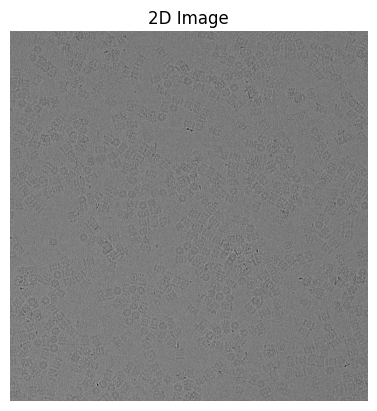

In [14]:
file_id = "1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr"
output = "map.mrc"

print("Downloading MRC file...")
gdown.download(id=file_id, output=output, quiet=False)


file_size = os.path.getsize(output)
print(f"\nFile size: {file_size / (1024**2):.2f} MB")

with open(output, "rb") as f:
    header = f.read(4)

print("First 4 bytes:", header)

if header.startswith(b"<"):
    raise ValueError("❌ Downloaded file is HTML, not MRC. Check sharing permissions.")

if file_size < 10000:
    raise ValueError("❌ File too small — likely incorrect download.")

print("✓ File appears valid")

print("\nLoading MRC file...")

with mrcfile.open(output, permissive=True) as mrc:
    if mrc.data is None:
        raise ValueError("❌ MRC file contains no readable data")
    data = mrc.data.copy()

print("✓ MRC loaded successfully")

print("\n" + "="*60)
print("MRC DATA INFO")
print("="*60)
print("Shape:", data.shape)
print("Dtype:", data.dtype)
print("Min/Max:", data.min(), data.max())


if data.ndim == 3:
    print("\nDetected: 3D volume")

    z, y, x = np.array(data.shape) // 2

    # ------------------------------------------
    # CENTRAL SLICES (RAW)
    # ------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    slices = [
        (data[z, :, :], "XY slice"),
        (data[:, y, :], "XZ slice"),
        (data[:, :, x], "YZ slice"),
    ]

    for ax, (img, title) in zip(axes, slices):
        vmin = np.percentile(img, 5)
        vmax = np.percentile(img, 95)
        ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    print("\nGenerating summed projections...")

    proj_xy = np.sum(data, axis=0)
    proj_xz = np.sum(data, axis=1)
    proj_yz = np.sum(data, axis=2)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    projections = [
        (proj_xy, "XY Projection (sum Z)"),
        (proj_xz, "XZ Projection (sum Y)"),
        (proj_yz, "YZ Projection (sum X)")
    ]

    for ax, (proj, title) in zip(axes, projections):
        vmin = np.percentile(proj, 5)
        vmax = np.percentile(proj, 95)
        ax.imshow(proj, cmap='gray', vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

elif data.ndim == 2:
    print("\nDetected: single 2D image")

    vmin = np.percentile(data, 5)
    vmax = np.percentile(data, 95)

    plt.imshow(data, cmap='gray', vmin=vmin, vmax=vmax)
    plt.title("2D Image")
    plt.axis('off')
    plt.show()

else:
    print("\n⚠️ Unrecognized format")

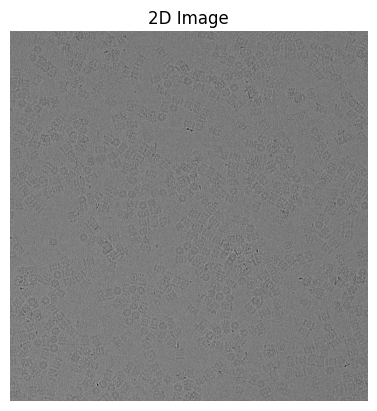

In [15]:
data
plt.imshow(data, cmap='gray', vmin=vmin, vmax=vmax)
plt.title("2D Image")
plt.axis('off')
plt.show()




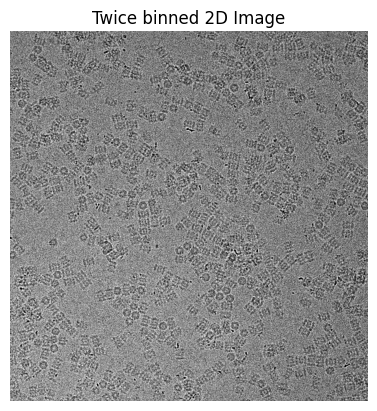

In [16]:
def bin_image(image, bin_size):
    """
    Performs binning (spatial downsampling) on an image.

    Args:
        image: Input image as numpy array
        bin_size: Size of the bin (e.g., 2 for 2x2 binning)

    Returns:
        Binned image with reduced resolution
    """
    h, w = image.shape
    # Calculate new dimensions
    new_h = h // bin_size
    new_w = w // bin_size

    # Reshape and compute mean of each bin
    binned = image[:new_h*bin_size, :new_w*bin_size].reshape(new_h, bin_size, new_w, bin_size)
    binned = binned.mean(axis=(1, 3)).astype(np.uint8)

    return binned

binned_data = bin_image(data, 5)
plt.imshow(bin_image(data, 5), cmap='gray', vmin=np.percentile(binned_data, 5), vmax=np.percentile(binned_data, 95))
plt.title("Twice binned 2D Image")
plt.axis('off')
plt.show()

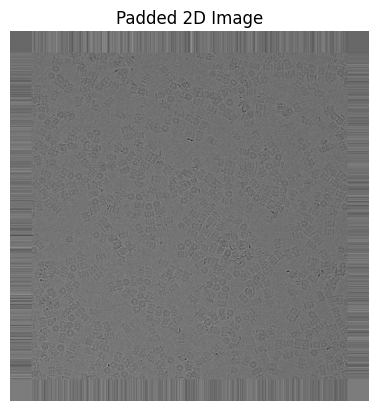

In [17]:


def apply_padding(img, pad_width, mode='constant', constant_value=255):
    """
    Apply padding to an image using NumPy.

    Parameters:
    -----------
    img : ndarray
        Input image
    pad_width : int or tuple
        Number of pixels to pad on each side
    mode : str
        Padding mode: 'constant', 'edge', 'reflect', 'wrap'
    constant_value : int
        Value used for constant padding

    Returns:
    --------
    padded : ndarray
        Padded image
    """
    if isinstance(pad_width, int):
        pad_width = ((pad_width, pad_width), (pad_width, pad_width))

    if mode == 'constant':
        padded = np.pad(img, pad_width, mode='constant', constant_values=constant_value)
    else:
        padded = np.pad(img, pad_width, mode=mode)

    return padded

padded_data = apply_padding(binned_data, 100, 'edge')
plt.imshow(padded_data, cmap='gray', vmin=np.percentile(data, 5), vmax=np.percentile(data, 95))
plt.title("Padded 2D Image")
plt.axis('off')
plt.show()


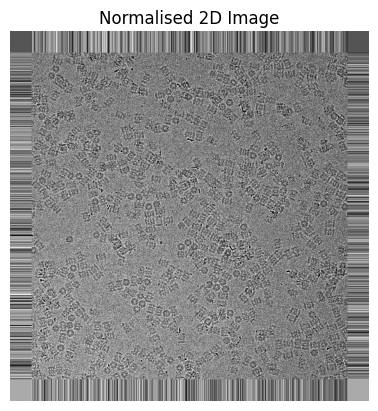

In [18]:

normalised_data = padded_data / data.max()
plt.imshow(normalised_data, cmap='gray', vmin=np.percentile(normalised_data, 5), vmax=np.percentile(normalised_data, 95))
plt.title("Normalised 2D Image")
plt.axis('off')
plt.show()

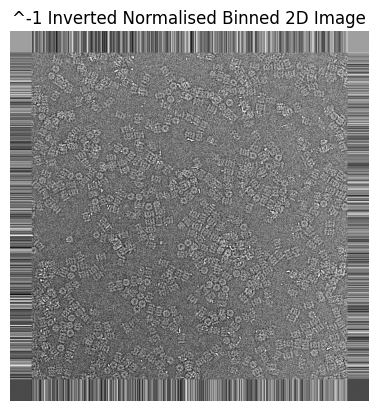

In [19]:
inverted_normalised_binned_data =1/normalised_data
plt.imshow(inverted_normalised_binned_data, cmap='gray', vmin=np.percentile(inverted_normalised_binned_data, 5), vmax=np.percentile(inverted_normalised_binned_data, 95))
plt.title("^-1 Inverted Normalised Binned 2D Image")
plt.axis('off')
plt.show()

#inverted_normalised_binned_data =-1*normalised_binned_data
#plt.imshow(inverted_normalised_binned_data, cmap='gray', vmin=np.percentile(inverted_normalised_binned_data, 5), vmax=np.percentile(inverted_normalised_binned_data, 95))
#plt.title("*-1 Inverted Normalised Binned 2D Image")
#plt.axis('off')
#plt.show()

Successfully downloaded 3885327 bytes
Saved to 6BDF.pdb

Template Information:
  Image Size: 36x36 pixels
  Calculated Pixel Size (X): 3.604 A/px
  Calculated Pixel Size (Y): 3.646 A/px


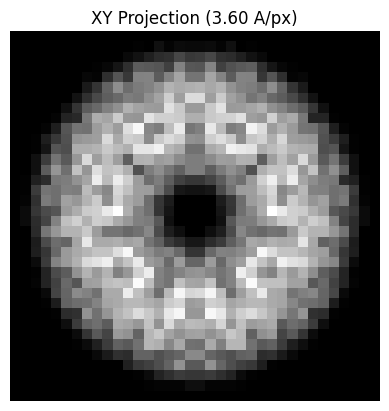

In [20]:
pdb_id = "6BDF"
pdb_url = f"https://files.rcsb.org/download/{pdb_id}.pdb"

try:
    print(f"Downloading {pdb_id} from RCSB PDB...")
    with urllib.request.urlopen(pdb_url, timeout=10) as response:
        pdb_content = response.read().decode('utf-8')
    print(f"Successfully downloaded {len(pdb_content)} bytes")

    # Save to file
    pdb_file = f"{pdb_id}.pdb"
    with open(pdb_file, 'w') as f:
        f.write(pdb_content)
    print(f"Saved to {pdb_file}")

    # Parse the PDB file
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure(pdb_id, pdb_file)

    # Extract information
    model = structure[0]
    all_atoms = []
    for chain in model.get_chains():
        for residue in chain.get_residues():
            for atom in residue.get_atoms():
                coord = atom.get_coord()
                all_atoms.append({
                    'x': coord[0], 'y': coord[1], 'z': coord[2]
                })

    coords = np.array([[atom['x'], atom['y'], atom['z']] for atom in all_atoms])

    # Center coordinates
    coords_centered = coords - coords.mean(axis=0)

    # Resolution settings
    img_size = 36  # pixels
    padding = 5     # Angstrom padding per side

    def create_projection(coord1, coord2, bins=36):
        min1, max1 = coord1.min() - padding, coord1.max() + padding
        min2, max2 = coord2.min() - padding, coord2.max() + padding

        # Calculate pixel size (Angstrom/pixel)
        pixel_size_x = (max1 - min1) / bins
        pixel_size_y = (max2 - min2) / bins

        H, xedges, yedges = np.histogram2d(coord1, coord2, bins=bins,
                                        range=[[min1, max1], [min2, max2]])
        return H / H.max(), pixel_size_x, pixel_size_y

    # Create projections
    proj_xy, psx, psy = create_projection(coords_centered[:, 0], coords_centered[:, 1], img_size)

    print(f"\nTemplate Information:")
    print(f"  Image Size: {img_size}x{img_size} pixels")
    print(f"  Calculated Pixel Size (X): {psx:.3f} A/px")
    print(f"  Calculated Pixel Size (Y): {psy:.3f} A/px")

    # Plot
    plt.imshow(proj_xy, cmap='gray')
    plt.title(f"XY Projection ({psx:.2f} A/px)")
    plt.axis('off')
    plt.show()

except Exception as e:
    print(f"Error: {e}")

XZ Image: 36x49 pixels (Resolution: 3.6 A/px)


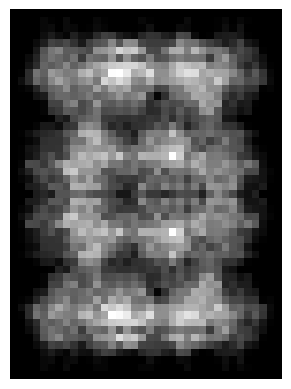

In [21]:
def project(c1, c2, res=3.6, pad=5):
    # Calculate dimensions based on target resolution (A/pixel)
    s1, s2 = (c1.max()-c1.min()) + 2*pad, (c2.max()-c2.min()) + 2*pad
    b1, b2 = int(np.round(s1/res)), int(np.round(s2/res))

    # Generate projection
    H, _, _ = np.histogram2d(c1, c2, bins=[b1, b2],
                             range=[[c1.min()-pad, c1.max()+pad], [c2.min()-pad, c2.max()+pad]])
    return H / H.max(), (b1, b2)

# Execute XZ projection
proj_xz, dims = project(coords_centered[:, 0], coords_centered[:, 2])

print(f"XZ Image: {dims[0]}x{dims[1]} pixels (Resolution: 3.6 A/px)")
plt.imshow(proj_xz.T, cmap='gray', origin='lower')
plt.axis('off')
plt.show()

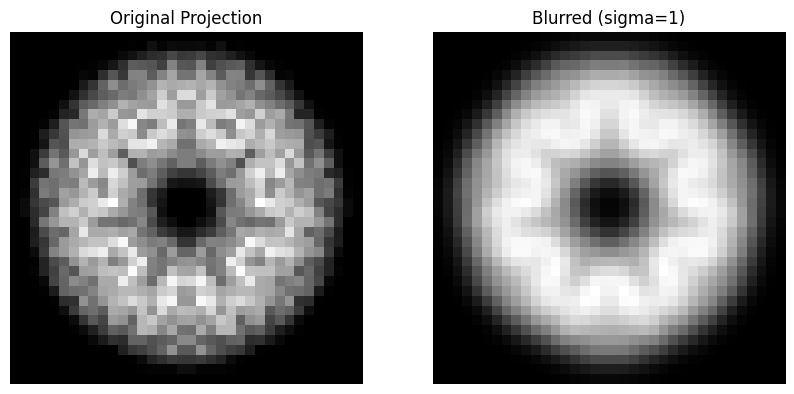

In [40]:

def blur_projection(projection, sigma=1.0):
    """
    Applies a Gaussian blur to a 2D projection.

    Args:
        projection: 2D numpy array (the template)
        sigma: Standard deviation for Gaussian kernel

    Returns:
        Blurred 2D numpy array
    """
    return gaussian_filter(projection, sigma=sigma)

# Example usage on the XY projection
sigma_val = 1
proj_xy_blurred = blur_projection(proj_xy, sigma=sigma_val)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(proj_xy, cmap='gray')
axes[0].set_title("Original Projection")
axes[0].axis('off')

axes[1].imshow(proj_xy_blurred, cmap='gray')
axes[1].set_title(f"Blurred (sigma={sigma_val})")
axes[1].axis('off')

plt.show()

In [41]:
def normalized_cross_correlation(image, template):
    """
    Perform normalized cross-correlation.

    Parameters:
    -----------
    image : 2D numpy array
        Input image
    template : 2D numpy array
        Template to search for

    Returns:
    --------
    output : 2D numpy array
        Normalized cross-correlation (values between -1 and 1)
    """
    img_h, img_w = image.shape
    tmp_h, tmp_w = template.shape

    out_h = img_h - tmp_h + 1
    out_w = img_w - tmp_w + 1

    output = np.zeros((out_h, out_w))

    # Normalize template (subtract mean)
    template_mean = template.mean()
    template_norm = template - template_mean
    template_std = np.sqrt(np.sum(template_norm ** 2))

    # Avoid division by zero
    if template_std == 0:
        return output

    # Slide template over image
    for i in range(out_h):
        for j in range(out_w):
            region = image[i:i+tmp_h, j:j+tmp_w]

            # Normalize region
            region_mean = region.mean()
            region_norm = region - region_mean
            region_std = np.sqrt(np.sum(region_norm ** 2))

            # Avoid division by zero
            if region_std == 0:
                output[i, j] = 0
            else:
                # Normalized cross-correlation
                output[i, j] = np.sum(region_norm * template_norm) / (region_std * template_std)

    return output


def template_matching(image, template, method='ncc'):
    """
    Perform template matching with padding.

    Parameters:
    -----------
    image : 2D numpy array
        Input image
    template : 2D numpy array
        Template to search for
    method : str
        'ncc' for normalized cross-correlation
        'cc' for simple cross-correlation

    Returns:
    --------
    result : 2D numpy array (same size as input image)
        Matching score map
    """
    tmp_h, tmp_w = template.shape
    pad_h, pad_w = tmp_h // 2, tmp_w // 2

    # Pad image
    padded = np.pad(image,
                    ((pad_h, pad_h), (pad_w, pad_w)),
                    mode='constant',
                    constant_values=0)

    # Perform matching
    if method == 'ncc':
        result = normalized_cross_correlation(padded, template)
    else:
        result = cross_correlation(padded, template)

    return result
match_result = template_matching(inverted_normalised_binned_data, proj_xy, method='ncc')
match_result_blur = template_matching(inverted_normalised_binned_data, proj_xy_blurred, method='ncc')


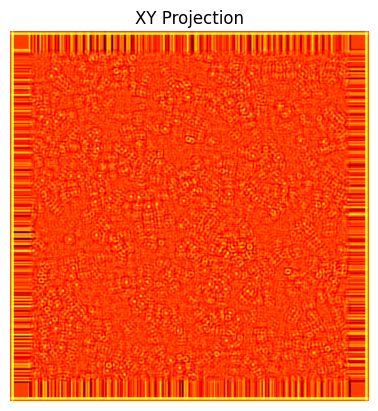

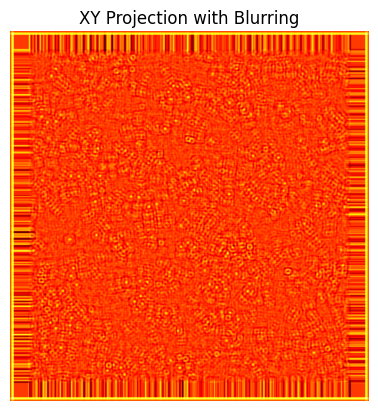

In [42]:
plt.imshow(match_result, cmap='hot')
plt.title("XY Projection")
plt.axis('off')
plt.show()

plt.imshow(match_result_blur, cmap='hot')
plt.title("XY Projection with Blurring")
plt.axis('off')
plt.show()

NCC Matching Map Statistics:
Min value: -0.4078
Max value: 0.4908
Mean value: 0.0074
Std deviation: 0.0769

Low (50% of max) (Threshold = 0.2454):
  Number of detections: 52293
  Peak coordinates (y, x):

Medium (66% of max) (Threshold = 0.3239):
  Number of detections: 14255
  Peak coordinates (y, x):


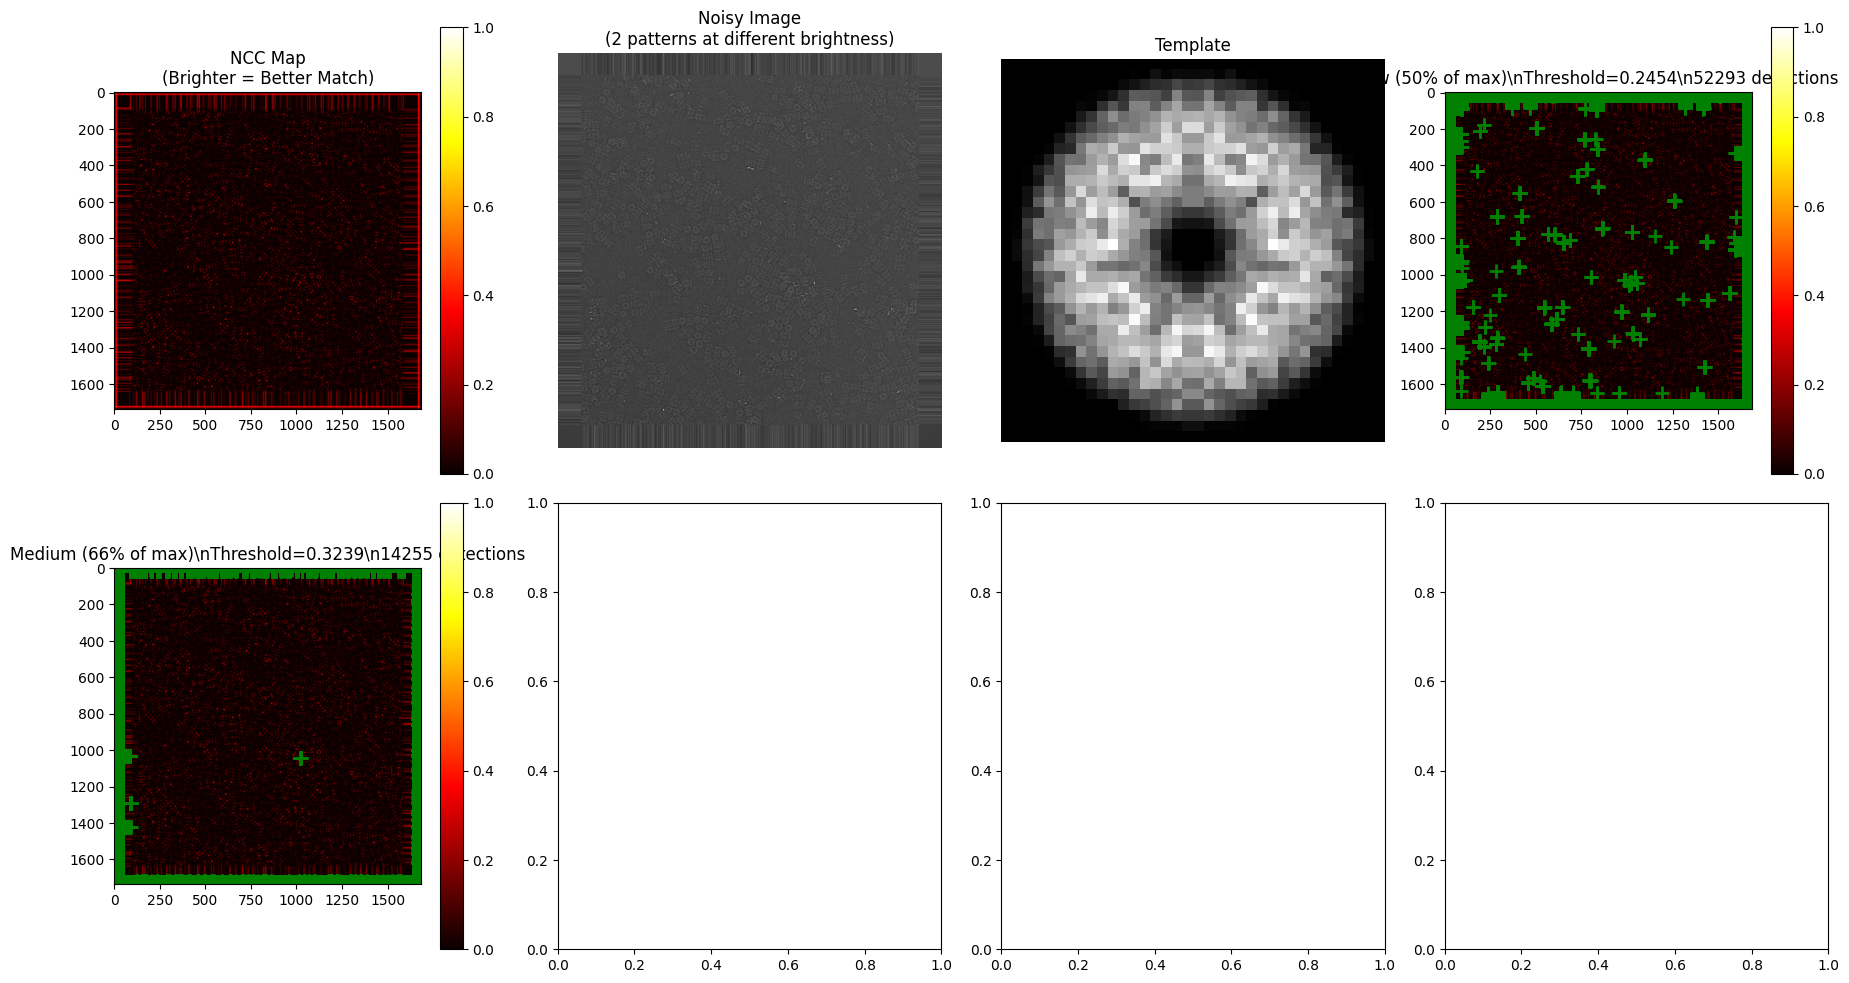

In [43]:
print("NCC Matching Map Statistics:")
print(f"Min value: {match_result.min():.4f}")
print(f"Max value: {match_result.max():.4f}")
print(f"Mean value: {match_result.mean():.4f}")
print(f"Std deviation: {match_result.std():.4f}")

# Try different threshold strategies
thresholds = {
    'Low (50% of max)': 0.5 * match_result.max(), 'Medium (66% of max)': 0.66* match_result.max() # , add here thresholds you want to try
}

# Visualize effect of different thresholds
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.ravel()

# Show original NCC map
im0 = axes[0].imshow(match_result, cmap='hot', vmin=0, vmax=1)
axes[0].set_title('NCC Map\n(Brighter = Better Match)')
plt.colorbar(im0, ax=axes[0])

# Show noisy image with patterns for reference
axes[1].imshow(inverted_normalised_binned_data, cmap='gray')
axes[1].set_title('Noisy Image\n(2 patterns at different brightness)')
axes[1].axis('off')

# Show template
axes[2].imshow(proj_xy, cmap='gray')
axes[2].set_title('Template')
axes[2].axis('off')

# Apply each threshold
for idx, (name, thresh_value) in enumerate(thresholds.items()):
    ax = axes[idx + 3]

    # Find matches above threshold
    detected_y, detected_x = np.where(match_result > thresh_value)

    # Print detected peak coordinates
    print(f"\n{name} (Threshold = {thresh_value:.4f}):")
    print(f"  Number of detections: {len(detected_x)}")
    if len(detected_x) > 0:
        print(f"  Peak coordinates (y, x):")
        for y, x in zip(detected_y, detected_x):
            score = match_result[y, x]
            #print(f"    ({y}, {x}) - Score: {score:.4f}")
    else:
        print("  No peaks detected")

    # Show NCC map with detected matches
    im = ax.imshow(match_result, cmap='hot', vmin=0, vmax=1)

    # Mark detected matches with green crosses
    ax.plot(detected_x, detected_y, 'g+',
            markersize=10, markeredgewidth=2)

    ax.set_title(f'{name}\\nThreshold={thresh_value:.4f}\\n{len(detected_x)} detections')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

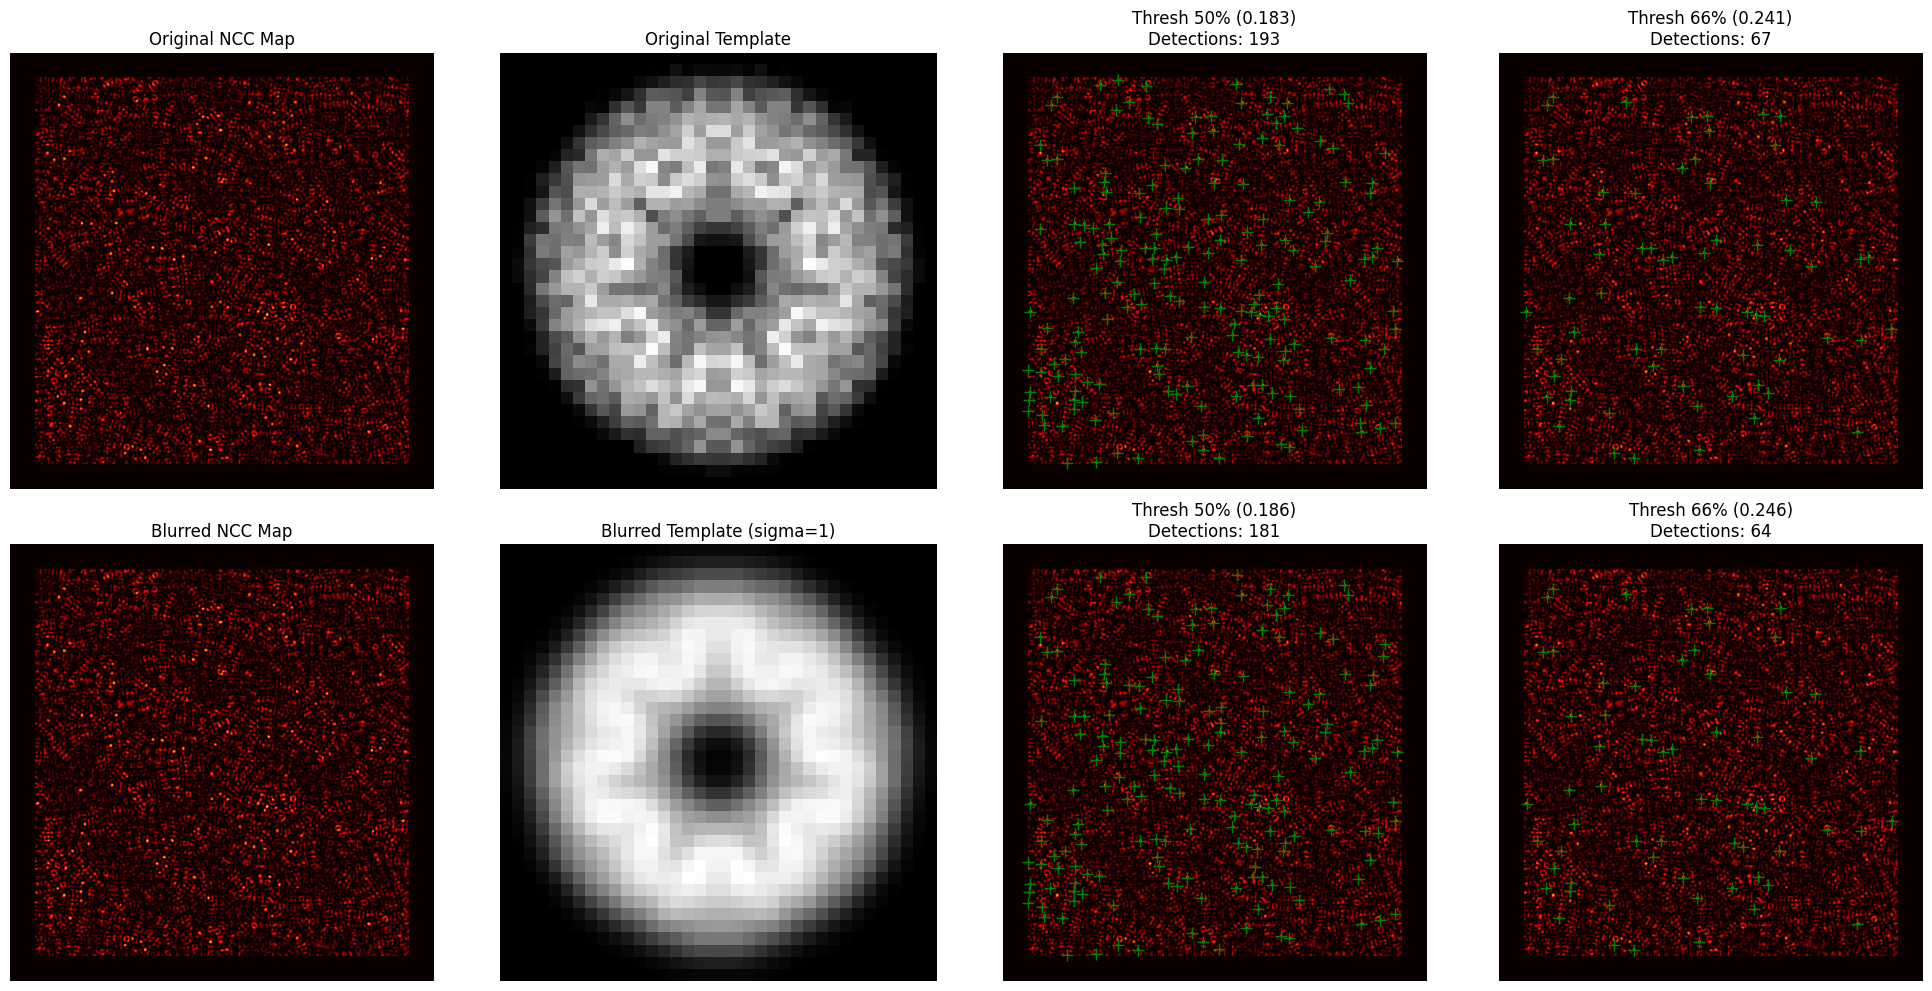

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import peak_local_max

# --- 1. PREPARE BOTH NCC MAPS (Ignore Borders) ---
padding = 100
min_separation = 30

def prepare_map(m):
    proc = m.copy()
    proc[:padding, :] = -1.0
    proc[-padding:, :] = -1.0
    proc[:, :padding] = -1.0
    proc[:, -padding:] = -1.0
    inner = m[padding:-padding, padding:-padding]
    return proc, inner

proc_orig, inner_orig = prepare_map(match_result)
proc_blur, inner_blur = prepare_map(match_result_blur)

# Define thresholds based on respective inner regions
threshold_pcts = [0.5, 0.66]

# Create a large comparison grid
# Rows: Original Template vs Blurred Template
# Columns: Reference info + Threshold variations
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Row 0: Original
axes[0, 0].imshow(proc_orig, cmap='hot', vmin=0, vmax=inner_orig.max())
axes[0, 0].set_title('Original NCC Map')
axes[0, 1].imshow(proj_xy, cmap='gray')
axes[0, 1].set_title('Original Template')

# Row 1: Blurred
axes[1, 0].imshow(proc_blur, cmap='hot', vmin=0, vmax=inner_blur.max())
axes[1, 0].set_title('Blurred NCC Map')
axes[1, 1].imshow(proj_xy_blurred, cmap='gray')
axes[1, 1].set_title(f'Blurred Template (sigma={sigma_val})')

# Apply detection and plot for both rows
for row_idx, (p_map, inner) in enumerate([(proc_orig, inner_orig), (proc_blur, inner_blur)]):
    for col_offset, pct in enumerate(threshold_pcts):
        ax = axes[row_idx, col_offset + 2]
        thresh = pct * inner.max()

        coords = peak_local_max(p_map, min_distance=min_separation, threshold_abs=thresh)

        ax.imshow(p_map, cmap='hot', vmin=0, vmax=inner.max())
        if len(coords) > 0:
            ax.plot(coords[:, 1], coords[:, 0], 'g+', markersize=8)

        ax.set_title(f'Thresh {int(pct*100)}% ({thresh:.3f})\nDetections: {len(coords)}')

for ax in axes.ravel():
    ax.axis('off')

plt.tight_layout()
plt.show()

In [65]:
def detect_and_plot_peaks(score_map, original_image, inner_region_ref, title_suffix="", threshold_pct=0.5, min_dist=50, margin=100):
    """
    Detects local peaks in a score map and visualizes them, ensuring margins are ignored.
    """
    # Copy the map to avoid modifying the original globally
    processed_map = score_map.copy()

    # Explicitly mask the margins to zero so they don't interfere with max() or peak detection
    if margin > 0:
        processed_map[:margin, :] = 0
        processed_map[-margin:, :] = 0
        processed_map[:, :margin] = 0
        processed_map[:, -margin:] = 0

    # 1. Calculate threshold based on the provided reference region (which is already centered)
    chosen_threshold = threshold_pct * inner_region_ref.max()

    # 2. Extract coordinates from the masked map
    final_coords = peak_local_max(
        processed_map,
        min_distance=min_dist,
        threshold_abs=chosen_threshold
    )

    # 3. Plot
    plt.figure(figsize=(10, 10))
    plt.imshow(original_image, cmap='gray')

    if len(final_coords) > 0:
        plt.plot(final_coords[:, 1], final_coords[:, 0], 'r+', markersize=15, markeredgewidth=2)
        plt.title(f'Detections: {len(final_coords)} peaks | Method: {title_suffix}', fontsize=12)
    else:
        plt.title(f'No patterns detected ({title_suffix})', fontsize=12)

    plt.axis('off')
    plt.show()

    return final_coords

### Unified Detection Interface
Select your preferred matching method below. FFT is significantly faster for large micrographs, while Spatial NCC is the traditional baseline.

Running Fourier (FFT) NCC Detection...


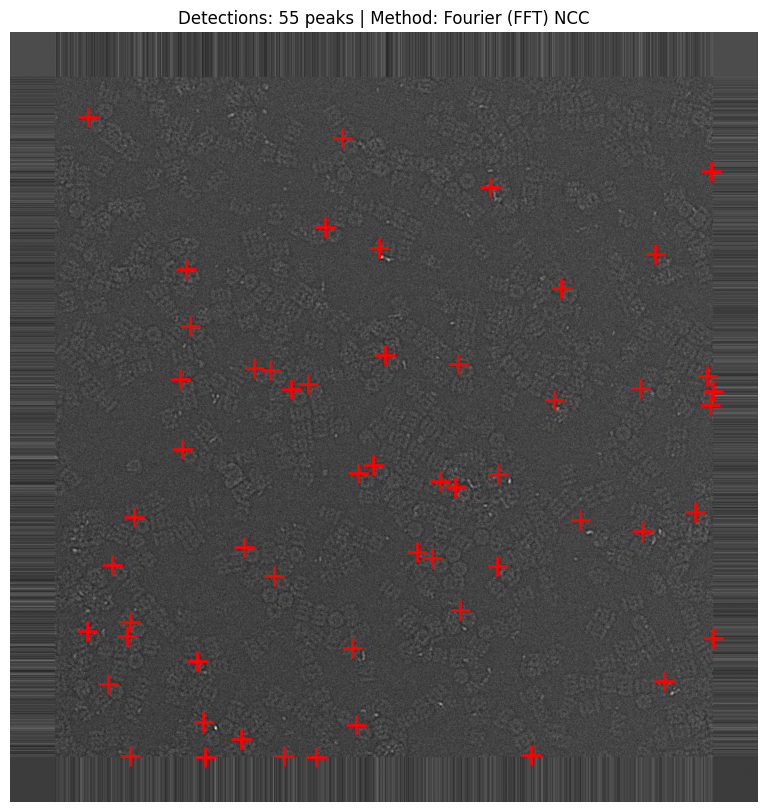

Done. Found 55 peaks using Fourier (FFT) NCC.


In [63]:
# --- CONFIGURATION ---
use_fft = True
threshold_pct = 0.66
min_dist = 30
margin = 100

if use_fft:
    print("Running Fourier (FFT) NCC Detection...")
    current_score_map = local_fft_ncc_map
    ref_region = current_score_map[margin:-margin, margin:-margin]
    method_label = "Fourier (FFT) NCC"
else:
    print("Running Spatial NCC Detection...")
    current_score_map = match_result_blur
    ref_region = current_score_map[margin:-margin, margin:-margin]
    method_label = "Spatial NCC"

# Run the detection and plotting
final_coordinates = detect_and_plot_peaks(
    score_map=current_score_map,
    original_image=inverted_normalised_binned_data,
    inner_region_ref=ref_region,
    title_suffix=method_label,
    threshold_pct=threshold_pct,
    min_dist=min_dist,
    margin=margin
)

print(f"Done. Found {len(final_coordinates)} peaks using {method_label}.")

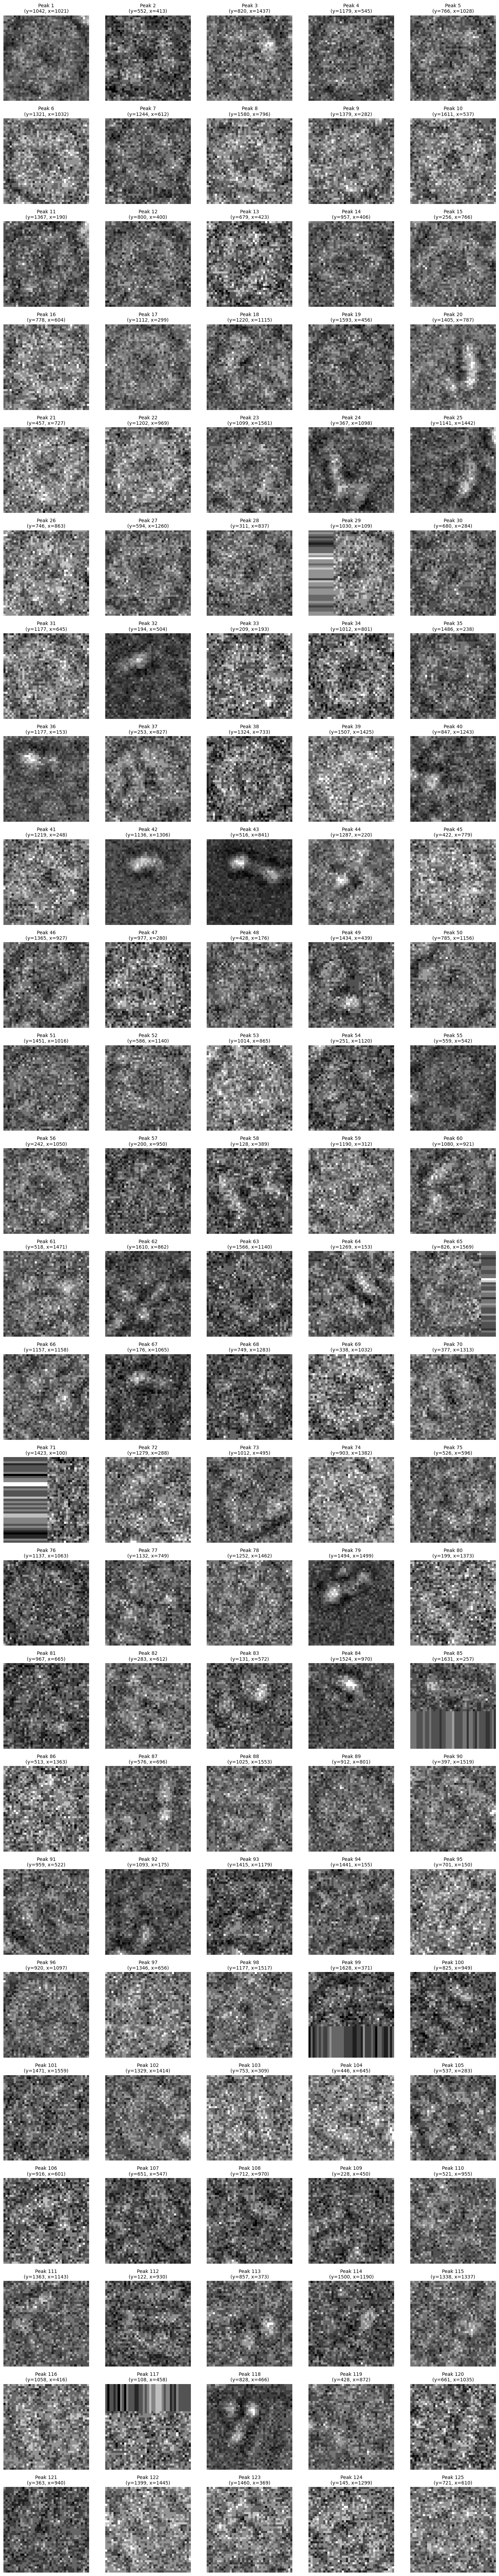

In [46]:
# Define the size of the box you want to cut out
patch_size = 40
half_size = patch_size // 2

num_peaks = len(final_coordinates)

if num_peaks > 0:
    # Dynamically size the gallery (up to 5 columns wide)
    cols = min(5, num_peaks)
    rows = int(np.ceil(num_peaks / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))

    # If there's only 1 peak, matplotlib doesn't return an array of axes, so we force it
    if num_peaks == 1:
        axes = np.array([axes])
    axes = axes.ravel()

    for i, (y, x) in enumerate(final_coordinates):
        # Calculate the bounding box (with safety checks in case a peak is near the absolute edge)
        y_start = max(0, y - half_size)
        y_end = min(inverted_normalised_binned_data.shape[0], y + half_size + 1)
        x_start = max(0, x - half_size)
        x_end = min(inverted_normalised_binned_data.shape[1], x + half_size + 1)

        # Slice the patch out of the original raw image
        patch = inverted_normalised_binned_data[y_start:y_end, x_start:x_end]

        # Plot it
        axes[i].imshow(patch, cmap='gray')
        axes[i].set_title(f'Peak {i+1}\n(y={y}, x={x})', fontsize=10)
        axes[i].axis('off')

    # Shut off any empty subplots in the final row
    for j in range(num_peaks, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No peaks detected! Lower the threshold to see patches.")

### Localized Sliding-Window FFT Correlation

To better localize the protein structures, we can slide our template across the image. For every position, we compute the FFT-based cross-correlation between the template and the underlying image window. This gives us a localized heatmap where high values indicate a strong match in frequency space.

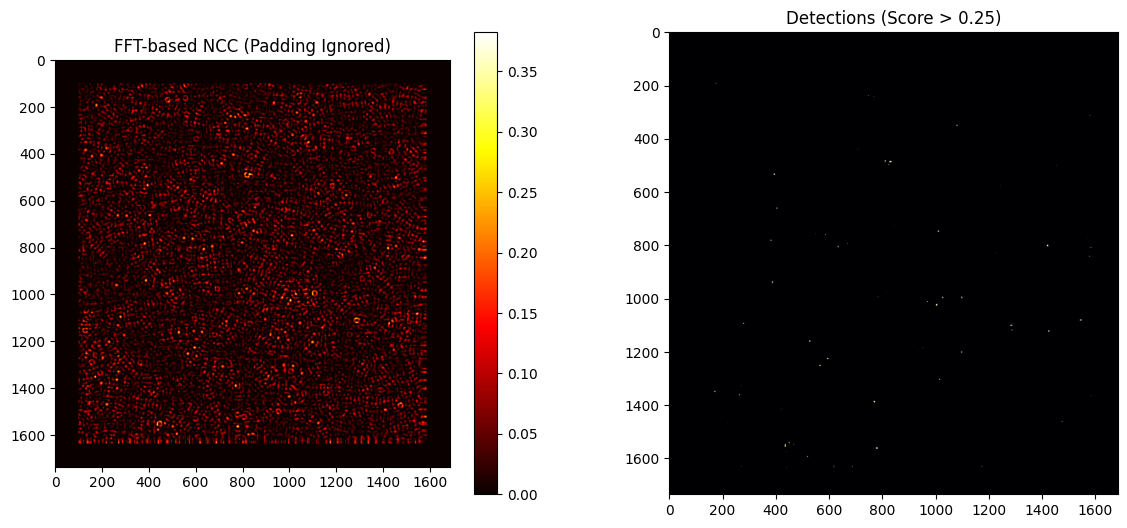

In [57]:
import scipy.fft as fft
from scipy.ndimage import uniform_filter

def fast_local_ncc(image, template, ignore_margin=100):
    """
    Fast Normalized Cross-Correlation using FFT and moving averages.
    Calculates NCC map scaled 0 to 1, ignoring boundaries.
    """
    image = image.astype(np.float32)
    template = template.astype(np.float32)

    t_h, t_w = template.shape
    # Normalize template to zero mean
    t_zero_mean = template - np.mean(template)
    t_sum_sq = np.sum(t_zero_mean**2)

    # 1. Numerator: FFT Correlation of (Image - LocalMean) and (Template)
    img_mean = uniform_filter(image, size=(t_h, t_w))
    img_diff = image - img_mean

    # Flip template for correlation (FFT convolution of flipped signal = correlation)
    t_flipped = np.flip(t_zero_mean)

    # Padding to next power of 2 for FFT efficiency
    s1 = image.shape[0] + t_h - 1
    s2 = image.shape[1] + t_w - 1
    fsize = (int(2**np.ceil(np.log2(s1))), int(2**np.ceil(np.log2(s2))))

    img_fft = fft.fft2(img_diff, fsize)
    tmp_fft = fft.fft2(t_flipped, fsize)

    # Raw correlation map
    full_corr = np.real(fft.ifft2(img_fft * tmp_fft))

    # Extract valid region and align with image features
    numerator = full_corr[t_h-1:t_h-1+image.shape[0], t_w-1:t_w-1+image.shape[1]]

    # 2. Denominator: Local Standard Deviation of image
    img_sq = image**2
    img_sum_sq = uniform_filter(img_sq, size=(t_h, t_w)) * (t_h * t_w)
    img_sum = uniform_filter(image, size=(t_h, t_w)) * (t_h * t_w)

    img_var = img_sum_sq - (img_sum**2) / (t_h * t_w)
    img_std = np.sqrt(np.maximum(img_var * t_sum_sq, 0))

    # 3. Combine with epsilon for stability
    ncc_map = np.zeros_like(numerator)
    mask = img_std > 1e-5
    ncc_map[mask] = numerator[mask] / img_std[mask]

    # Apply the clipping [0, 1]
    ncc_map = np.clip(ncc_map, 0, 1)

    # Ignore the padding: Set margins to 0
    if ignore_margin > 0:
        ncc_map[:ignore_margin, :] = 0
        ncc_map[-ignore_margin:, :] = 0
        ncc_map[:, :ignore_margin] = 0
        ncc_map[:, -ignore_margin:] = 0

    return ncc_map

# Run the improved FFT NCC with boundary masking
local_fft_ncc_map = fast_local_ncc(inverted_normalised_binned_data, proj_xy, ignore_margin=100)

# Visualization
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(local_fft_ncc_map, cmap='hot')
plt.title("FFT-based NCC (Padding Ignored)")
plt.colorbar()

plt.subplot(1, 2, 2)
# Threshold at 66% of peak
thresh_val = 0.66 * local_fft_ncc_map.max()
plt.imshow(local_fft_ncc_map > thresh_val, cmap='magma')
plt.title(f"Detections (Score > {thresh_val:.2f})")
plt.show()

In [28]:
requirements = [
    'numpy',
    'matplotlib',
    'opencv-python',
    'tifffile',
    'scipy',
    'Pillow',
    'requests',
    'scikit-image',
    'biopython',
    'mrcfile',
    'gdown'
]

with open('requirements.txt', 'w') as f:
    for lib in requirements:
        f.write(f'{lib}\n')

print('✓ requirements.txt has been created.')

✓ requirements.txt has been created.
